In [ ]:
import sys

!{sys.executable} -m pip install -q \
    langchain>=0.3.0 \
    langchain-chroma>=0.1.0 \
    langchain-community>=0.3.0 \
    langchain-huggingface>=0.1.0 \
    langgraph>=0.2.0 \
    langchain-ollama>=0.2.0 \
    chromadb>=0.5.0 \
    sentence-transformers>=3.0.0 \
    torch>=2.0.0 \
    tqdm>=4.66.0 \
    pypdf>=4.0.0

print("Dépendances installées")

Dépendances installées


'e:\ENSET' n'est pas reconnu en tant que commande interne
ou externe, un programme ex�cutable ou un fichier de commandes.


In [ ]:
from pathlib import Path

# Chemins 
BASE_DIR        = Path(".")          # dossier du notebook
DATA_DIR        = BASE_DIR / "data"
PDF_DIR         = DATA_DIR / "pdfs"
CHROMA_DIR      = DATA_DIR / "chroma_db"


LLM_MODEL_NAME       = "llama3.2:3b"      # modele Ollama local
EMBEDDING_MODEL_NAME = "all-MiniLM-L6-v2" # leger, rapide, ~80 MB
COLLECTION_NAME      = "cholera_guidelines"

# Chunking & retrieval 
CHUNK_SIZE    = 300
CHUNK_OVERLAP = 30
RETRIEVAL_K   = 4
MAX_REWRITES  = 2

EMBEDDING_DEVICE     = "cpu"   
EMBEDDING_BATCH_SIZE = 8     

print(f"PDF_DIR    : {PDF_DIR.resolve()}")
print(f"CHROMA_DIR : {CHROMA_DIR.resolve()}")
print(f" Device     : {EMBEDDING_DEVICE}")
print(f"Batch size : {EMBEDDING_BATCH_SIZE}")

PDF_DIR    : E:\ENSET MOHAMMEDIA\MASTER 1\AI_TRUE\Evaluation_finale\data\pdfs
CHROMA_DIR : E:\ENSET MOHAMMEDIA\MASTER 1\AI_TRUE\Evaluation_finale\data\chroma_db
 Device     : cpu
Batch size : 8


In [ ]:
import urllib.request

PDF_DIR.mkdir(parents=True, exist_ok=True)

SOURCES = {
    "who_cholera_outbreak_response.pdf": [
        "https://www.gtfcc.org/wp-content/uploads/2020/05/gtfcc-cholera-outbreak-response-field-manual-2024.pdf",
        "https://www.gtfcc.org/wp-content/uploads/2020/02/gtfcc-cholera-outbreak-response-field-manual.pdf",
    ],
    "who_cholera_surveillance.pdf": [
        "https://www.gtfcc.org/wp-content/uploads/2025/04/public-health-surveillance-for-cholera-guidance-document-2024.pdf",
        "https://www.gtfcc.org/wp-content/uploads/2019/02/gtfcc-guidance-on-the-use-of-oral-cholera-vaccines.pdf",
    ],
    "who_ors_guidelines.pdf": [
        "https://files.givewell.org/files/DWDA%202009/Interventions/ORS/WHO_Oral_rehydration_salts_report_2006.pdf",
    ],
    "msf_management_of_a_cholera_epidemic.pdf": [
        "https://medicalguidelines.msf.org/sites/default/files/pdf/guideline-800-en.pdf",
    ],
}

HEADERS = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) Chrome/120.0.0.0 Safari/537.36",
    "Accept": "application/pdf,*/*",
}

def is_valid_pdf(path: Path) -> bool:
    try:
        with open(path, "rb") as f:
            return f.read(4) == b"%PDF"
    except Exception:
        return False

def try_download(url: str, dest: Path) -> bool:
    try:
        req = urllib.request.Request(url, headers=HEADERS)
        with urllib.request.urlopen(req, timeout=60) as r:
            data = r.read()
        if data[:4] != b"%PDF":
            print(f" Réponse non-PDF (probablement HTML/403)")
            return False
        dest.write_bytes(data)
        return True
    except Exception as exc:
        print(f"   Échec : {exc}")
        return False

success = 0
for filename, urls in SOURCES.items():
    dest = PDF_DIR / filename
    if dest.exists() and is_valid_pdf(dest):
        print(f"Déjà présent ({dest.stat().st_size//1024} KB) : {filename}")
        success += 1
        continue
    if dest.exists():
        dest.unlink()
    downloaded = False
    for i, url in enumerate(urls, 1):
        print(f"Tentative {i}/{len(urls)} : {filename}")
        if try_download(url, dest):
            print(f"   OK ({dest.stat().st_size//1024} KB)")
            success += 1
            downloaded = True
            break
    if not downloaded:
        print(f" ÉCHEC : placez le PDF manuellement dans {PDF_DIR}")

print(f"\n{success}/{len(SOURCES)} PDFs disponibles")

Déjà présent (1977 KB) : who_cholera_outbreak_response.pdf
Déjà présent (3805 KB) : who_cholera_surveillance.pdf
Déjà présent (2349 KB) : who_ors_guidelines.pdf
Déjà présent (2231 KB) : msf_management_of_a_cholera_epidemic.pdf

4/4 PDFs disponibles


In [ ]:
for pdf_path in sorted(PDF_DIR.glob("*.pdf")):
    size_kb = pdf_path.stat().st_size / 1024
    with open(pdf_path, "rb") as f:
        header = f.read(10)
    valid = header[:4] == b"%PDF"
    status = "OK" if valid else "INVALIDE"
    print(f"{status} | {size_kb:>8.0f} KB | {pdf_path.name}")

OK |     2232 KB | msf_management_of_a_cholera_epidemic.pdf
OK |     1978 KB | who_cholera_outbreak_response.pdf
OK |     3805 KB | who_cholera_surveillance.pdf
OK |     2349 KB | who_ors_guidelines.pdf


In [ ]:
import gc
import torch
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm.auto import tqdm

from langchain_chroma import Chroma
from langchain_community.document_loaders import PyPDFLoader
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter

# chargement des PDF 
def load_pdf(pdf_path: Path) -> list:
    try:
        with open(pdf_path, "rb") as f:
            if f.read(4) != b"%PDF":
                print(f"[IGNORE] {pdf_path.name}")
                return []
        docs = PyPDFLoader(str(pdf_path)).load()
        print(f"[OK] {pdf_path.name} — {len(docs)} pages")
        return docs
    except Exception as exc:
        print(f"[ERREUR] {pdf_path.name} : {exc}")
        return []

pdf_files = sorted(PDF_DIR.glob("*.pdf"))
if not pdf_files:
    raise FileNotFoundError(f"Aucun PDF dans {PDF_DIR}. Lancez la cellule 3.")

documents = []
with ThreadPoolExecutor(max_workers=2) as executor:   # 2 workers max pour économiser la RAM
    futures = {executor.submit(load_pdf, p): p for p in pdf_files}
    for future in tqdm(as_completed(futures), total=len(pdf_files), desc="Chargement PDF"):
        documents.extend(future.result())

print(f"\n Total : {len(documents)} pages chargées")

# Decoupage en chunks 
splitter = RecursiveCharacterTextSplitter(
    chunk_size=CHUNK_SIZE,
    chunk_overlap=CHUNK_OVERLAP,
    add_start_index=True,
)
chunks = splitter.split_documents(documents)
del documents  
gc.collect()
print(f" {len(chunks)} chunks créés")

# Embeddings
print(f"\Chargement du modèle d'embedding sur {EMBEDDING_DEVICE}...")
embeddings = HuggingFaceEmbeddings(
    model_name=EMBEDDING_MODEL_NAME,
    model_kwargs={"device": EMBEDDING_DEVICE},
    encode_kwargs={"batch_size": EMBEDDING_BATCH_SIZE},
)
print("Modèle chargé")

# La construction du vectorstore
# Supprimer l'ancien vectorstore si existant afin d'eviter les conflits
if CHROMA_DIR.exists():
    import shutil
    shutil.rmtree(CHROMA_DIR)
    print("Ancien vectorstore supprimé")

print(f"\n Construction du vectorstore ({len(chunks)} chunks × embed) — peut prendre 5–15 min sur CPU...")
print(" Le PC ne s'éteindra pas car on utilise le CPU (pas le GPU) avec un batch limité.")

vectorstore = Chroma.from_documents(
    documents=chunks,
    embedding=embeddings,
    collection_name=COLLECTION_NAME,
    persist_directory=str(CHROMA_DIR),
)

count = vectorstore._collection.count()
print(f"\n Vectorstore construit : {count} chunks indexés dans {CHROMA_DIR}")

<>:49: SyntaxWarning: "\C" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\C"? A raw string is also an option.
<>:49: SyntaxWarning: "\C" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\C"? A raw string is also an option.
C:\Users\Parfait DIMBA\AppData\Local\Temp\ipykernel_7092\1469368535.py:49: SyntaxWarning: "\C" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\C"? A raw string is also an option.
  print(f"\Chargement du modèle d'embedding sur {EMBEDDING_DEVICE}...")


[OK] who_cholera_outbreak_response.pdf — 148 pages


[OK] who_cholera_surveillance.pdf — 115 pages


[OK] msf_management_of_a_cholera_epidemic.pdf — 282 pages


Chargement PDF: 100%|██████████| 4/4 [01:06<00:00, 16.57s/it]

[OK] who_ors_guidelines.pdf — 123 pages

 Total : 668 pages chargées


 3908 chunks créés
\Chargement du modèle d'embedding sur cpu...


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1376.43it/s]


Modèle chargé
Ancien vectorstore supprimé

 Construction du vectorstore (3908 chunks × embed) — peut prendre 5–15 min sur CPU...
 Le PC ne s'éteindra pas car on utilise le CPU (pas le GPU) avec un batch limité.


In [29]:
from operator import add
from pathlib import Path
from typing import Literal

from langchain.tools import tool
from langchain_core.messages import AnyMessage, HumanMessage, SystemMessage, ToolMessage
from langchain_ollama import ChatOllama
from langchain_community.vectorstores import Chroma
from langchain_community.embeddings import HuggingFaceEmbeddings
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.graph import END, START, StateGraph
from typing_extensions import Annotated, TypedDict

LLM_MODEL_NAME       = "llama3.2:3b"           
COLLECTION_NAME      = "cholera_docs"     
EMBEDDING_MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"  
EMBEDDING_DEVICE     = "cpu"
EMBEDDING_BATCH_SIZE = 32
CHROMA_DIR           = Path("./chroma_db")
RETRIEVAL_K          = 4                
MAX_REWRITES         = 2                 

class AgentState(TypedDict):
    messages: Annotated[list[AnyMessage], add]
    llm_calls: int
    rewrite_count: int
    retrieved_docs: list[str]
    last_tool_names: list[str]
    docs_relevant: bool


@tool
def compute_ors_dosage(weight_kg: float, dehydration_level: str) -> dict:
    """Calcule la dose de SRO recommandée selon le poids et le niveau de déshydratation.
    Args:
        weight_kg: poids du patient en kg.
        dehydration_level: 'legere', 'moderee' ou 'severe'.
    """
    level = dehydration_level.strip().lower()
    ml_per_kg = {"legere": 50, "moderee": 75, "severe": 100}
    if level not in ml_per_kg:
        return {"error": f"Niveau inconnu : '{dehydration_level}'. Valeurs : 'legere', 'moderee', 'severe'."}
    volume_ml = weight_kg * ml_per_kg[level]
    return {
        "weight_kg": weight_kg,
        "dehydration_level": level,
        "ors_volume_ml_4h": round(volume_ml, 0),
        "ors_volume_liters_4h": round(volume_ml / 1000, 2),
        "note": "Volume sur 4h. En cas de vomissements, fractionner en petites gorgées fréquentes.",
    }


@tool
def estimate_attack_rate(cases: int, population: int) -> dict:
    """Calcule le taux d'attaque d'une épidémie de choléra.
    Args:
        cases: nombre de cas suspects ou confirmés.
        population: population totale de la zone.
    """
    if population <= 0:
        return {"error": "La population doit être > 0."}
    attack_rate = (cases / population) * 100
    return {
        "cases": cases,
        "population": population,
        "attack_rate_percent": round(attack_rate, 4),
        "cases_per_1000": round((cases / population) * 1000, 2),
        "who_alert_threshold_exceeded": attack_rate > 1.0,
        "note": "Seuil OMS : taux d'attaque > 1 % en contexte d'urgence.",
    }


@tool
def retrieve_documents(query: str) -> str:
    """Recherche les passages les plus pertinents dans la base documentaire sur le choléra.
    Args:
        query: question ou mots-clés à rechercher.
    """
    vs = Chroma(
        collection_name=COLLECTION_NAME,
        embedding_function=HuggingFaceEmbeddings(
            model_name=EMBEDDING_MODEL_NAME,
            model_kwargs={"device": EMBEDDING_DEVICE},
            encode_kwargs={"batch_size": EMBEDDING_BATCH_SIZE},
        ),
        persist_directory=str(CHROMA_DIR),
    )
    docs = vs.similarity_search(query, k=RETRIEVAL_K)
    if not docs:
        return "Aucun document pertinent trouvé."
    parts = []
    for doc in docs:
        source = Path(doc.metadata.get("source", "inconnu")).name
        page = doc.metadata.get("page", "?")
        parts.append(f"[Source: {source}, page {page}]\n{doc.page_content}")
    return "\n\n---\n\n".join(parts)


TOOLS = [retrieve_documents, compute_ors_dosage, estimate_attack_rate]
TOOLS_BY_NAME = {t.name: t for t in TOOLS}

model = ChatOllama(model=LLM_MODEL_NAME, temperature=0)
model_with_tools = model.bind_tools(TOOLS)

SYSTEM_PROMPT = (
    "Tu es un assistant spécialisé dans la gestion des épidémies de choléra : "
    "surveillance épidémiologique, réponse de terrain, réhydratation orale (SRO), "
    "prévention et contrôle. "
    "Utilise l'outil retrieve_documents pour t'appuyer sur les guides OMS, GTFCC et MSF "
    "avant de répondre à une question de connaissance générale. "
    "Utilise compute_ors_dosage pour calculer les doses de SRO. "
    "Utilise estimate_attack_rate pour calculer le taux d'attaque d'une épidémie. "
    "Réponds en français, de façon claire et précise, et cite tes sources."
)


def agent_node(state: AgentState) -> dict:
    response = model_with_tools.invoke(
        [SystemMessage(content=SYSTEM_PROMPT)] + state["messages"]
    )
    return {"messages": [response], "llm_calls": state.get("llm_calls", 0) + 1}


def tools_node(state: AgentState) -> dict:
    last = state["messages"][-1]
    results, tool_names, retrieved_docs = [], [], state.get("retrieved_docs", [])
    for call in last.tool_calls:
        tool = TOOLS_BY_NAME[call["name"]]
        try:
            observation = tool.invoke(call["args"])
        except Exception as exc:
            observation = f"Erreur : {call['name']} a échoué ({exc})."
        results.append(ToolMessage(content=str(observation), tool_call_id=call["id"]))
        tool_names.append(call["name"])
        if call["name"] == "retrieve_documents":
            retrieved_docs = [str(observation)]
    return {"messages": results, "last_tool_names": tool_names, "retrieved_docs": retrieved_docs}


def grade_documents_node(state: AgentState) -> dict:
    question = next((m.content for m in reversed(state["messages"]) if isinstance(m, HumanMessage)), "")
    docs_text = "\n\n".join(state.get("retrieved_docs", []))
    prompt = (
        f"Question : {question}\n\nDocuments récupérés :\n{docs_text}\n\n"
        "Ces documents contiennent-ils des informations utiles ? Réponds uniquement par 'oui' ou 'non'."
    )
    response = model.invoke([HumanMessage(content=prompt)])
    return {"docs_relevant": "oui" in response.content.strip().lower()}


def rewrite_query_node(state: AgentState) -> dict:
    question = next((m.content for m in reversed(state["messages"]) if isinstance(m, HumanMessage)), "")
    prompt = (
        f"La question suivante n'a pas trouvé de documents pertinents : '{question}'. "
        "Reformule-la avec des termes différents. Réponds uniquement avec la question reformulée."
    )
    response = model.invoke([HumanMessage(content=prompt)])
    return {
        "messages": [HumanMessage(content=response.content.strip())],
        "rewrite_count": state.get("rewrite_count", 0) + 1,
    }


def route_after_agent(state: AgentState) -> Literal["tools", "__end__"]:
    return "tools" if getattr(state["messages"][-1], "tool_calls", None) else END


def route_after_tools(state: AgentState) -> Literal["grade_documents", "agent"]:
    return "grade_documents" if "retrieve_documents" in state.get("last_tool_names", []) else "agent"


def route_after_grading(state: AgentState) -> Literal["agent", "rewrite_query"]:
    return "agent" if state.get("docs_relevant", True) or state.get("rewrite_count", 0) >= MAX_REWRITES else "rewrite_query"


builder = StateGraph(AgentState)
builder.add_node("agent", agent_node)
builder.add_node("tools", tools_node)
builder.add_node("grade_documents", grade_documents_node)
builder.add_node("rewrite_query", rewrite_query_node)
builder.add_edge(START, "agent")
builder.add_conditional_edges("agent", route_after_agent, ["tools", END])
builder.add_conditional_edges("tools", route_after_tools, ["grade_documents", "agent"])
builder.add_conditional_edges("grade_documents", route_after_grading, ["agent", "rewrite_query"])
builder.add_edge("rewrite_query", "agent")

graph = builder.compile(checkpointer=InMemorySaver())
print("Graphe LangGraph compilé")

Graphe LangGraph compilé


---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	agent(agent)
	tools(tools)
	grade_documents(grade_documents)
	rewrite_query(rewrite_query)
	__end__([<p>__end__</p>]):::last
	__start__ --> agent;
	agent -.-> __end__;
	agent -.-> tools;
	grade_documents -.-> agent;
	grade_documents -.-> rewrite_query;
	rewrite_query --> agent;
	tools -.-> agent;
	tools -.-> grade_documents;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc


 Copiez le texte ci-dessus sur https://mermaid.live pour le visualiser


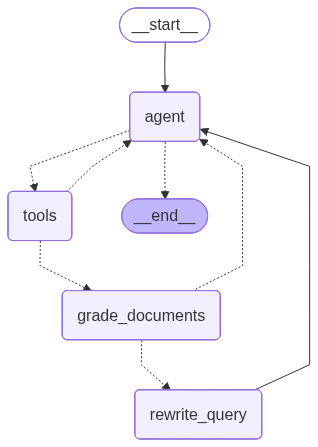

In [4]:
mermaid_src = graph.get_graph().draw_mermaid()
print(mermaid_src)
print("\n Copiez le texte ci-dessus sur https://mermaid.live pour le visualiser")


try:
    from IPython.display import Image, display
    png = graph.get_graph().draw_mermaid_png()
    display(Image(png))
except Exception as e:
    print(f"PNG non disponible : {e}")

In [ ]:
QUESTION = "Quels sont les principaux symptômes du choléra ?"

config = {"configurable": {"thread_id": "notebook-session"}}
result = graph.invoke({"messages": [HumanMessage(content=QUESTION)]}, config)

print(f" Question : {QUESTION}")
print(f"\n Réponse :\n{result['messages'][-1].content}")
print(f"\n LLM calls : {result.get('llm_calls', 0)} | Rewrites : {result.get('rewrite_count', 0)}")

In [ ]:
BASE_DIR = Path(".")
config = {"configurable": {"thread_id": "notebook-chat"}}

print(" Assistant Choléra")
print("Tapez 'exit' pour arrêter.\n")

while True:
    try:
        question = input("Vous : ").strip()
    except (EOFError, KeyboardInterrupt):
        print("Session terminée.")
        break
    if not question or question.lower() in {"exit", "quit"}:
        break
    result = graph.invoke({"messages": [HumanMessage(content=question)]}, config)
    print(f"\nAssistant : {result['messages'][-1].content}\n")


 Assistant Choléra
Tapez 'exit' pour arrêter.



In [15]:
import csv
import time
from pathlib import Path

BASE_DIR = Path(".")
RESULTS_DIR = BASE_DIR / "evaluation" / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

SIMPLE_QUESTIONS = [
    "Quels sont les principaux symptômes du choléra ?",
    "Comment se transmet le choléra ?",
    "Qu'est-ce qu'une solution de réhydratation orale (SRO) ?",
    "Quel est le rôle de la surveillance épidémiologique dans une épidémie de choléra ?",
    "Qu'est-ce qu'un taux d'attaque dans le contexte d'une épidémie ?",
    "Quelles sont les principales mesures de prévention du choléra selon l'OMS ?",
    "Qu'est-ce qu'un centre de traitement du choléra (CTC) ?",
    "Comment préparer une solution de SRO à domicile ?",
    "Quelles populations sont les plus vulnérables au choléra ?",
    "Quel est le rôle du GTFCC dans la lutte contre le choléra ?",
]

COMPLEX_QUESTIONS = [
    "Un enfant de 15 kg présente une déshydratation modérée. Quelle dose de SRO doit-il recevoir selon les recommandations OMS, et comment fractionner l'administration en cas de vomissements ?",
    "Dans une zone de 50 000 habitants, 320 cas de choléra ont été recensés en une semaine. Calcule le taux d'attaque et indique si le seuil d'alerte OMS est dépassé.",
    "Quelles sont les étapes clés d'une réponse d'urgence à une épidémie de choléra selon le manuel de terrain GTFCC, et comment prioriser les actions dans les 48 premières heures ?",
    "Compare les approches de prise en charge d'un patient en déshydratation sévère versus modérée selon les guides OMS et MSF.",
    "Quelles sont les stratégies de surveillance épidémiologique du choléra recommandées par le GTFCC, et comment distinguer un cas suspect d'un cas confirmé ?",
    "Comment établir un système d'approvisionnement en eau potable et d'assainissement dans un camp de déplacés pour prévenir une épidémie de choléra ?",
    "Un adulte de 70 kg présente une déshydratation sévère. Calcule le volume de SRO nécessaire sur 4 heures, puis explique quand passer à la réhydratation intraveineuse.",
    "Quel est le rôle de la vaccination contre le choléra dans la stratégie globale de réponse, et dans quels contextes le vaccin oral est-il recommandé en priorité ?",
    "Quelles sont les différences entre la surveillance sentinelle et la surveillance exhaustive du choléra ?",
    "Dans deux zones comparables, la zone A (100 000 hab.) enregistre 800 cas et la zone B (60 000 hab.) enregistre 540 cas. Compare leurs taux d'attaque et identifie la zone prioritaire.",
]

def run_question(qid: str, qtype: str, question: str) -> dict:
    config = {"configurable": {"thread_id": f"eval-{qid}"}}
    t0 = time.perf_counter()
    result = graph.invoke({"messages": [HumanMessage(content=question)]}, config)
    elapsed = round(time.perf_counter() - t0, 2)
    return {
        "id": qid,
        "type": qtype,
        "question": question,
        "answer": result["messages"][-1].content,
        "time_s": elapsed,
        "sources": " | ".join(result.get("retrieved_docs", []))[:500],
        "llm_calls": result.get("llm_calls", 0),
        "rewrites": result.get("rewrite_count", 0),
    }

rows = []
for i, q in enumerate(SIMPLE_QUESTIONS, 1):
    print(f"[{i}/20] Simple   : {q[:65]}...")
    rows.append(run_question(f"S{i}", "simple", q))

for i, q in enumerate(COMPLEX_QUESTIONS, 1):
    print(f"[{i+10}/20] Complexe : {q[:65]}...")
    rows.append(run_question(f"C{i}", "complexe", q))

csv_path = RESULTS_DIR / "results.csv"
with open(csv_path, "w", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(f, fieldnames=list(rows[0].keys()))
    writer.writeheader()
    writer.writerows(rows)

print(f"\nRésultats écrits dans {csv_path}")


[1/20] Simple   : Quels sont les principaux symptômes du choléra ?...


NameError: name 'graph' is not defined

In [ ]:
import sys
!{sys.executable} -m pip install -q pandas

import csv
from pathlib import Path

BASE_DIR = Path(".")
csv_path = BASE_DIR / "evaluation" / "results" / "results.csv"

with open(csv_path, newline="", encoding="utf-8") as f:
    reader = csv.DictReader(f)
    rows = list(reader)


from collections import defaultdict
by_type = defaultdict(list)
for r in rows:
    by_type[r["type"]].append(r)

print("=== Résumé par type ===")
print(f"{'Type':<12} {'Temps moy (s)':<16} {'Appels LLM':<14} {'Reformulations'}")
print("-" * 56)
for typ, group in sorted(by_type.items()):
    avg_time    = sum(float(r["time_s"])   for r in group) / len(group)
    avg_llm     = sum(float(r["llm_calls"]) for r in group) / len(group)
    avg_rewrites= sum(float(r["rewrites"]) for r in group) / len(group)
    print(f"{typ:<12} {avg_time:<16.2f} {avg_llm:<14.2f} {avg_rewrites:.2f}")

total = sum(float(r["time_s"]) for r in rows)
mean  = total / len(rows)
print(f"\nTemps total : {total:.1f}s  |  Temps moyen : {mean:.1f}s")

print("\n=== Réponses ===")
for row in rows:
    answer = row["answer"]
    short  = (answer[:300] + "...") if len(answer) > 300 else answer
    print(f"\n[{row['id']}] {row['question'][:80]}")
    print(f"→ {short}")
    print(f"   ⏱ {row['time_s']}s | {row['llm_calls']} appels LLM | rewrites: {row['rewrites']}")
